In [4]:
## Initialzing and loading required libraries and subfunctions
import numpy as np
import matplotlib.pyplot as plt
import copy
import yasa
from mne.filter import resample
import pynapple as nap
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import normalize
import requests
from io import BytesIO
import sails
import re
from scipy.stats import entropy
import os, sys

import scipy
from scipy import signal
from scipy.interpolate import griddata
from scipy.signal import correlate
from scipy.stats import pearsonr
from scipy.fft import fft
from scipy.spatial.distance import euclidean
from scipy.signal import spectrogram
from scipy.io import loadmat
import scipy.fft
import scipy.stats
import scipy.io as sio
from scipy.signal import hilbert

import emd as emd
import emd.sift as sift
import emd.spectra as spectra

from neurodsp.sim import sim_combined
from neurodsp.plts import plot_time_series, plot_timefrequency
from neurodsp.utils import create_times
from neurodsp.timefrequency.wavelets import compute_wavelet_transform
from neurodsp.filt import filter_signal

# Load required libraries
import numpy as np
from scipy.io import loadmat
from scipy.signal import hilbert
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from neurodsp.filt import filter_signal, filter_signal_fir, design_fir_filter
import emd
import pandas as pd
from sklearn.preprocessing import Normalizer
from tqdm import tqdm
import plotly.express as px
import copy
import umap.umap_ as umap
import skdim
from scipy.spatial import cKDTree
import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable

## UTILS

for rel in ('src', '../src'):
    p = os.path.abspath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

from utils import *
from detect_pt import *

from scipy.io import loadmat
import numpy as np
from neurodsp.filt import filter_signal
import copy
import emd
from scipy.spatial import cKDTree
from tqdm import tqdm

sns.set(style='white', context='notebook')

In [5]:
path_to_config = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/src/emd_masksift_CA1_config_2500.yml'
config = emd.sift.SiftConfig.from_yaml_file(path_to_config)

In [6]:
path_to_hpc = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/HPC_100_CH32_0.continuous.mat'
path_to_states = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/2018-11-02_14-17-36_post_trial5-states.mat'

In [7]:
lfpHPC, hypno, fs = get_data(path_to_hpc, path_to_states)

In [8]:
phasic_interval, tonic_interval, lfp = extract_pt_intervals(lfpHPC, hypno)

15-Oct-25 00:21:00 | WARNING | Hypnogram is SHORTER than data by 0.74 seconds. Padding hypnogram with last value to match data.size.


Number of detected Tonic intrevals:30
Number of detected Tonic intrevals after threshold:30


In [9]:
tonic_imfs, tonic_imfs_freqs, tonic_rem_lpf = extract_imfs_by_pt_intervals(lfp, fs, tonic_interval, config, return_imfs_freqs=True)
phasic_imfs, phasic_imfs_freqs, rem_lpf = extract_imfs_by_pt_intervals(lfp, fs, phasic_interval, config, return_imfs_freqs=True)

In [ ]:
def extract_cycle_info(imfs, imf_frequencies):

  waveforms = pd.DataFrame()
  all_trials = pd.DataFrame()
  raw_wavelets = []
  all_FPPs = []

  theta_range = [5, 12]
  frequencies = np.arange(15, 141, 1)
  angles=np.linspace(-180,180,19)
  fs = 2500

  for idx, imf in enumerate(imfs):
    cycle_data = get_cycle_data(imf[:, 5], fs=2500)

    amp_thresh = np.percentile(cycle_data['IA'], 25) # higher than 25th percentile of the data
    lo_freq_duration = fs/5  # restrict the analysis to 5-12 Hz
    hi_freq_duration = fs/12

    conditions = ['is_good==1',
                        f'duration_samples<{lo_freq_duration}',
                        f'duration_samples>{hi_freq_duration}',
                        f'max_amp>{amp_thresh}']
    print(len(cycle_data['theta_imf']))
    all_cycles = get_cycles_with_conditions(cycle_data['cycles'], conditions)
    
    # Check if any cycles satisfy the conditions
    if all_cycles is None or all_cycles.chain_vect.size == 0:
        print("No cycles satisfy the conditions.")
        return pd.DataFrame(), pd.DataFrame(), []
    
    subset_cycles_df = all_cycles.get_metric_dataframe(subset=True)
    subset_indices = subset_cycles_df['index'].values

    all_cycles_inds = get_cycle_inds(all_cycles, subset_indices)
    cycles_inds = arrange_cycle_inds(all_cycles_inds)

    freqs = imf_frequencies[idx]
    sub_theta, theta, supra_theta = tg_split(freqs, theta_range)
    supra_theta_sig = np.sum(imf.T[supra_theta], axis=0)

    # # Corrected Wavelet Transform Computation
    raw_data=sails.wavelet.morlet(supra_theta_sig, freqs=frequencies, sample_rate=fs, ncycles=5,ret_mode='power', normalise=None)
    raw_wavelets.append(raw_data)
    supraPlot = scipy.stats.zscore(raw_data, axis=1)
    FPP = bin_tf_to_fpp(cycles_inds, supraPlot, bin_count=19)
    all_FPPs.append(FPP)

    # Compute mode frequency for each cycle
    mode_freqs, entropies = compute_mode_frequency_and_entropy(FPP, frequencies, angles)

    all_waveforms, _ = emd.cycles.phase_align(cycle_data['IP'], cycle_data['theta_imf'],
                                                            cycles=all_cycles.iterate(through='subset'), npoints=100)
    all_waveforms = pd.DataFrame(all_waveforms.T)

    waveforms = pd.concat([waveforms, all_waveforms])

    trial = all_cycles.get_metric_dataframe(subset=True)
    trial['mode_freqs'] = mode_freqs
    trial['entropy'] = entropies
    all_trials = pd.concat([all_trials, trial])

  return waveforms, all_trials, all_FPPs, raw_wavelets

In [ ]:
phasic_waveforms, phasic_trials, phasic_FPPs, phasic_raw_wavelets = extract_cycle_info(phasic_imfs, phasic_imfs_freqs)
tonic_waveforms, tonic_trials, tonic_FPPs, tonic_raw_wavelets = extract_cycle_info(tonic_imfs, tonic_imfs_freqs)

In [ ]:
# ========= NEW HELPERS (non-invasive) =========
import numpy as np
import warnings
import pandas as pd
import sails
import emd
from emd.spectra import frequency_transform  # for Hilbert IP/IF/IA

def _choose_theta_imf(imf, fs, theta_band=(5.0, 12.0), min_inband_frac=0.60):
    """
    Only used as a fallback if IMF index 5 is not valid/theta-like.
    Prefers IMFs spending >= min_inband_frac inside theta_band; else nearest median IF.
    """
    n_imf = imf.shape[1]
    lo, hi = theta_band
    IFs = []
    for k in range(n_imf):
        _, IF_k, _ = frequency_transform(imf[:, k], fs, 'hilbert')
        IFs.append(IF_k)
    IFs = np.vstack(IFs)                     # [n_imf, n_samples]
    frac_inband = ((IFs >= lo) & (IFs <= hi)).mean(axis=1)
    med_if = np.median(IFs, axis=1)
    band_center = 0.5 * (lo + hi)
    cand = np.where(frac_inband >= min_inband_frac)[0]
    if cand.size:
        return int(cand[np.argmin(np.abs(med_if[cand] - band_center))])
    warnings.warn("No IMF met min_inband_frac; using IMF with median IF closest to theta center.")
    return int(np.argmin(np.abs(med_if - band_center)))

def _cycle_time_indices_from_bins(cycles_inds):
    """
    Your FPP path gives phase-binned indices per cycle.
    Convert each cycle’s bins to a flat, unique list of time indices.
    """
    out = []
    for cyc in cycles_inds:
        arr = np.asarray(cyc)
        flat = arr.ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size == 0:
            out.append(np.array([], dtype=int))
            continue
        flat = flat.astype(int, copy=False)
        flat = flat[(flat >= 0)]
        out.append(np.unique(flat))
    return out

def _spectral_signatures_time_mean(supra_sig, fs, cycle_time_idx_list,
                                   freqs=np.arange(15, 141, 1), wavelet_ncycles=5):
    """
    Paper-faithful signatures: Morlet power on supra-theta signal (15–140 Hz),
    then per-cycle MEAN across time samples inside that cycle (no phase binning / z-scoring).
    Returns:
        sigs  -> (n_cycles, n_freq)
        tf    -> (n_freq, n_time) full time-frequency power (useful for debugging)
    """
    tf = sails.wavelet.morlet(
        supra_sig, freqs=freqs, sample_rate=fs,
        ncycles=wavelet_ncycles, ret_mode='power', normalise=None
    )
    sigs = []
    T = tf.shape[1]
    for tids in cycle_time_idx_list:
        tids = np.asarray(tids)
        tids = tids[(tids >= 0) & (tids < T)]
        if tids.size == 0:
            sigs.append(np.full(len(freqs), np.nan))
        else:
            sigs.append(tf[:, tids].mean(axis=1))
    if len(sigs) == 0:
        return np.zeros((0, len(freqs))), tf
    return np.vstack(sigs), tf

def prepare_time_signatures(imfs, imf_frequencies, lfp_segments,
                            fs=2500, theta_imf_index_prefer=5,
                            theta_band=(5.0, 12.0),
                            freq_vec=np.arange(15, 141, 1)):
    """
    Produces per-cycle spectral signatures (15–140 Hz) using supra-theta = sum of supra-theta IMFs.
    """

    time_signatures_list = []

    for idx, imf in enumerate(imfs):
        # 1) pick theta IMF index (prefer fixed, fallback if needed)
        if imf.shape[1] > theta_imf_index_prefer:
            theta_idx = theta_imf_index_prefer
        else:
            theta_idx = _choose_theta_imf(imf, fs, theta_band=theta_band)

        # 2) get cycles with your conditions
        cycle_data = get_cycle_data(imf[:, theta_idx], fs=fs)
        amp_thresh = np.percentile(cycle_data['IA'], 25)
        lo_freq_duration = fs/5
        hi_freq_duration = fs/12
        conditions = ['is_good==1',
                      f'duration_samples<{lo_freq_duration}',
                      f'duration_samples>{hi_freq_duration}',
                      f'max_amp>{amp_thresh}']
        all_cycles = get_cycles_with_conditions(cycle_data['cycles'], conditions)
        if all_cycles is None or all_cycles.chain_vect.size == 0:
            time_signatures_list.append(np.zeros((0, len(freq_vec))))
            continue

        subset_cycles_df = all_cycles.get_metric_dataframe(subset=True)
        subset_indices = subset_cycles_df['index'].values

        all_cycles_inds = get_cycle_inds(all_cycles, subset_indices)
        cycles_inds = arrange_cycle_inds(all_cycles_inds)
        tids = _cycle_time_indices_from_bins(cycles_inds)

        # 3) supra-theta = sum of supra-theta IMFs (paper-style definition)
        freqs = imf_frequencies[idx]
        _, theta_mask, supra_mask = tg_split(freqs, theta_band)
        theta_imf = imf[:, theta_mask].sum(axis=1) if np.any(theta_mask) else imf[:, theta_idx]
        supra_theta_sig = imf[:, supra_mask].sum(axis=1) if np.any(supra_mask) else np.zeros_like(theta_imf)

        # 4) per-cycle time-mean spectral signatures
        sigs_time, _tf = _spectral_signatures_time_mean(
            supra_theta_sig, fs, tids, freqs=freq_vec, wavelet_ncycles=5
        )
        time_signatures_list.append(sigs_time)

    return time_signatures_list

def extract_data_for_rat(rat_id):
    # Define the base path to OS Basic datasets
    base_path = '/Users/amir/Desktop/for Abdel/OS Basic'
    fs = 2500  # Sample frequency

    # Initialize empty DataFrames for concatenation across all recordings and trials for the specified rat
    all_combined_waveforms = pd.DataFrame()
    all_combined_trials = pd.DataFrame()
    all_phasic_fpps = []
    all_tonic_fpps = []

    all_phasic_time_sigs = []
    all_tonic_time_sigs = []

    rat_path = os.path.join(base_path, str(rat_id))

    # Check if the specified rat folder exists
    if not os.path.isdir(rat_path):
        print(f"Rat folder {rat_id} does not exist.")
        return None, None

    # List all recording folders in the rat directory
    recording_folders = [
        f for f in os.listdir(rat_path)
        if os.path.isdir(os.path.join(rat_path, f))
    ]

    if not recording_folders:
        print(f"No recording folders found for Rat {rat_id}.")
        return None, None

    # Loop over each recording folder
    for recording_folder in recording_folders:
        print(f"Processing recording folder: {recording_folder}")
        recording_path = os.path.join(rat_path, recording_folder)

        # Use regular expressions to parse the folder name
        match = re.match(r'^Rat-OS-Ephys_(Rat\d+)_SD(\d+)_([\w-]+)_([\d-]+)$', recording_folder)
        if not match:
            print(f"Unexpected folder name format: {recording_folder}. Skipping...")
            continue

        rat_id_part = match.group(1)       # e.g., 'Rat6'
        sd_number = match.group(2)         # e.g., '4'
        condition = match.group(3)         # e.g., 'CON'
        date_part = match.group(4)         # e.g., '22-02-2018'

        rat_id_from_folder = ''.join(filter(str.isdigit, rat_id_part))

        # Check if rat_id_from_folder matches rat_id
        if rat_id_from_folder != str(rat_id):
            print(f"Rat ID mismatch in folder {recording_folder}. Expected Rat{rat_id}, found Rat{rat_id_from_folder}. Skipping...")
            continue

        # Detect all trial folders and filter for post_trial2 to post_trial5, considering various folder name formats
        trial_folders = [
            f for f in os.listdir(recording_path)
            if os.path.isdir(os.path.join(recording_path, f)) and
            re.search(r'(?i)post[\-_]?trial[\-_]?([2-5])', f)
        ]

        if not trial_folders:
            print(f"No trial folders found in {recording_folder}.")
            continue

        for trial_folder in trial_folders:
            print(f"Processing trial folder: {trial_folder}")
            trial_path = os.path.join(recording_path, trial_folder)

            # Search for LFP and state files in the trial folder
            lfp_file = None
            state_file = None

            for file_name in os.listdir(trial_path):
                if 'HPC' in file_name and file_name.endswith('.mat'):
                    lfp_file = os.path.join(trial_path, file_name)
                elif 'states' in file_name and file_name.endswith('.mat'):
                    state_file = os.path.join(trial_path, file_name)
                elif 'States' in file_name and file_name.endswith('.mat'):
                    state_file = os.path.join(trial_path, file_name)

            # Ensure both LFP and state files were found
            if not lfp_file or not state_file:
                print(f"Missing LFP or state file in {trial_path}. Skipping...")
                continue

            # Extract trial number from folder name
            trial_number_match = re.search(r'(?i)post[\-_]?trial[\-_]?([2-5])', trial_folder)
            if trial_number_match:
                trial_number = int(trial_number_match.group(1))
            else:
                print(f"Unable to extract trial number from folder name: {trial_folder}. Skipping...")
                continue

            # Load data using custom functions
            try:
                lfpHPC, hypno, _ = get_data(lfp_file, state_file)

                # Extract phasic and tonic intervals, handling cases with no REM sleep
                try:
                    phasic_interval, tonic_interval, lfp = extract_pt_intervals(lfpHPC, hypno)
                except ValueError as e:
                    print(f"No REM sleep found in {trial_folder} for Rat {rat_id}, Condition {condition}. Filling with empty intervals.")
                    phasic_interval, tonic_interval, lfp = [[], [], []]

                # Extract IMFs and frequencies for phasic and tonic intervals if intervals are not empty
                if phasic_interval and tonic_interval:
                    # Get IMFs + imf_freqs + raw segments per interval
                    tonic_imfs, tonic_freqs, tonic_lpf = extract_imfs_by_pt_intervals(
                        lfp, fs, tonic_interval, config, return_imfs_freqs=True)
                    phasic_imfs, phasic_freqs, phasic_lpf = extract_imfs_by_pt_intervals(
                        lfp, fs, phasic_interval, config, return_imfs_freqs=True)

                    # === existing path: FPP/UMAP ===
                    phasic_waveforms, phasic_trials, phasic_fpps, _ = extract_cycle_info(phasic_imfs, phasic_freqs)
                    tonic_waveforms,  tonic_trials,  tonic_fpps, _  = extract_cycle_info(tonic_imfs,  tonic_freqs)

                    # === NEW parallel path: 15–140 Hz time-mean spectral signatures ===
                    phasic_time_sigs = prepare_time_signatures(
                        phasic_imfs, phasic_freqs, phasic_lpf, fs=fs,
                        theta_imf_index_prefer=5, theta_band=(5,12),
                        freq_vec=np.arange(15,141,1)
                    )
                    tonic_time_sigs = prepare_time_signatures(
                        tonic_imfs, tonic_freqs, tonic_lpf, fs=fs,
                        theta_imf_index_prefer=5, theta_band=(5,12),
                        freq_vec=np.arange(15,141,1)
                    )

                    # Add metadata columns, including cycle type labels
                    for df in [phasic_waveforms, phasic_trials]:
                        df['rat_id'] = rat_id
                        df['condition'] = condition
                        df['trial'] = trial_number
                        df['cycle_type'] = 'phasic'
                        df['SD'] = sd_number
                        df['date'] = date_part

                    for df in [tonic_waveforms, tonic_trials]:
                        df['rat_id'] = rat_id
                        df['condition'] = condition
                        df['trial'] = trial_number
                        df['cycle_type'] = 'tonic'
                        df['SD'] = sd_number
                        df['date'] = date_part

                    # Concatenate into combined DataFrames / lists
                    all_combined_waveforms = pd.concat(
                        [all_combined_waveforms, phasic_waveforms, tonic_waveforms], ignore_index=True)
                    all_combined_trials = pd.concat(
                        [all_combined_trials, phasic_trials, tonic_trials], ignore_index=True)
                    all_phasic_fpps.extend(phasic_fpps)
                    all_tonic_fpps.extend(tonic_fpps)

                    # NEW: collect time-mean signature sets
                    all_phasic_time_sigs.extend(phasic_time_sigs)
                    all_tonic_time_sigs.extend(tonic_time_sigs)

            except FileNotFoundError:
                print(f"Data not found in {trial_path}. Skipping...")

    if all_combined_waveforms.empty:
        print(f"No data extracted for Rat {rat_id}.")
        return None, None

    # NOTE: we append two NEW return values (time-mean signatures) at the end.
    return (all_combined_waveforms, all_combined_trials,
            all_phasic_fpps, all_tonic_fpps,
            all_phasic_time_sigs, all_tonic_time_sigs)

In [ ]:
rat_id = '11'
waveforms_df,trials_df, all_phasic_FPPs, all_tonic_FPPs, phasic_time_signatures, tonic_time_signatures= extract_data_for_rat(rat_id)

print(f"FPPs — phasic intervals: {len(all_phasic_FPPs)}, tonic intervals: {len(all_tonic_FPPs)}")
print(f"Time-mean signatures — phasic intervals: {len(phasic_time_signatures)}, tonic intervals: {len(tonic_time_signatures)}")

In [ ]:
import os
import numpy as np
import pandas as pd

# Optional smoothing util (uses SciPy if available; otherwise a small Gaussian conv fallback)
try:
    from scipy.ndimage import gaussian_filter1d
    _HAS_SCI = True
except Exception:
    _HAS_SCI = False

def _smooth_rows(mat, sigma_hz, mode="reflect"):
    if _HAS_SCI:
        return gaussian_filter1d(mat, sigma=float(sigma_hz), axis=1, mode=mode)
    # fallback conv
    sigma = float(sigma_hz)
    rad = int(np.ceil(4 * sigma))
    kx = np.arange(-rad, rad + 1)
    ker = np.exp(-(kx**2) / (2 * sigma**2))
    ker /= ker.sum()
    pad = rad
    out = np.empty_like(mat)
    for i in range(mat.shape[0]):
        row = mat[i]
        if mode == "reflect":
            row_pad = np.r_[row[pad:0:-1], row, row[-2:-pad-2:-1]]
        elif mode == "constant":
            row_pad = np.r_[np.zeros(pad), row, np.zeros(pad)]
        else:
            row_pad = np.r_[row[pad:0:-1], row, row[-2:-pad-2:-1]]
        out[i] = np.convolve(row_pad, ker, mode="same")[pad:-pad]
    return out

def compute_mode_freq_featZ_smooth_for_session_imfs(
    imfs, imf_frequencies, fs=2500, theta_band=(5,12),
    freq_vec=np.arange(15,141,1), wavelet_ncycles=5,
    smooth_sigma_hz=5.0, ignore_edge_bins=1, theta_imf_index_prefer=5
):
    """
    For a list of IMFs (one per segment) from a single session:
      1) detect theta cycles with your conditions
      2) compute per-cycle time-mean spectral signatures on supra-theta (15–140 Hz)
      3) Z-score across cycles (per frequency), smooth across frequency
      4) pick the mode frequency from the smoothed Z (ignoring first/last bins if desired)
    Returns:
      modes_hz : np.ndarray (n_cycles,)   -- mode_freq_hz_featZ_smooth for each kept cycle
      idx_map  : list of (interval_idx, local_cycle_idx) tuples (same order as modes_hz)
      X_raw    : np.ndarray (n_cycles, n_freq) raw time-mean signatures (optional inspection)
      Xz_smooth: np.ndarray (n_cycles, n_freq) smoothed Z (what we used to pick the mode)
    """
    rows = []
    idx_map = []

    for idx, imf in enumerate(imfs):
        # 1) choose theta IMF index
        if imf.shape[1] > theta_imf_index_prefer:
            theta_idx = theta_imf_index_prefer
        else:
            theta_idx = _choose_theta_imf(imf, fs, theta_band=theta_band)

        # 2) cycles with your conditions
        cycle_data = get_cycle_data(imf[:, theta_idx], fs=fs)
        amp_thresh = np.percentile(cycle_data['IA'], 25)
        lo_freq_duration = fs/5
        hi_freq_duration = fs/12
        conditions = ['is_good==1',
                      f'duration_samples<{lo_freq_duration}',
                      f'duration_samples>{hi_freq_duration}',
                      f'max_amp>{amp_thresh}']
        all_cycles = get_cycles_with_conditions(cycle_data['cycles'], conditions)
        if all_cycles is None or all_cycles.chain_vect.size == 0:
            continue

        subset_df = all_cycles.get_metric_dataframe(subset=True)
        subset_indices = subset_df['index'].values
        all_cycles_inds = get_cycle_inds(all_cycles, subset_indices)
        cycles_inds     = arrange_cycle_inds(all_cycles_inds)
        tids_list      = _cycle_time_indices_from_bins(cycles_inds)

        # 3) supra-theta signal (sum of IMFs with mean freq > 12 Hz)
        freqs = imf_frequencies[idx]
        _, theta_mask, supra_mask = tg_split(freqs, theta_band)
        supra_theta_sig = imf[:, supra_mask].sum(axis=1) if np.any(supra_mask) else np.zeros(imf.shape[0])

        # 4) per-cycle time-mean spectral signatures (15–140 Hz)
        sigs_time, _tf = _spectral_signatures_time_mean(
            supra_theta_sig, fs, tids_list, freqs=freq_vec, wavelet_ncycles=wavelet_ncycles
        )  # (n_cycles_i × n_freq)

        # keep finite rows only; remember mapping
        if sigs_time.size:
            mask = np.isfinite(sigs_time).all(axis=1)
            Xi = sigs_time[mask]
            if Xi.size:
                start_j = len(idx_map)
                rows.append(Xi)
                for j in range(Xi.shape[0]):
                    idx_map.append((idx, j))  # interval idx & local cycle idx

    if len(rows) == 0:
        return np.zeros((0,)), [], np.zeros((0, len(freq_vec))), np.zeros((0, len(freq_vec)))

    X = np.vstack(rows)                       # raw cycle signatures
    # 5) feature Z across cycles (per frequency)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, ddof=1, keepdims=True) + 1e-12
    Xz = (X - mu) / sd

    # 6) smooth across frequency
    Xz_smooth = _smooth_rows(Xz, sigma_hz=smooth_sigma_hz, mode="reflect")

    # 7) pick mode (ignore edges if requested)
    L, R = ignore_edge_bins, (Xz_smooth.shape[1] - ignore_edge_bins)
    if R > L:
        idx_rel = np.argmax(Xz_smooth[:, L:R], axis=1)
        idx_max = idx_rel + L
    else:
        idx_max = np.argmax(Xz_smooth, axis=1)
    modes_hz = freq_vec[idx_max]

    return modes_hz, idx_map, X, Xz_smooth

# ========== RUN FOR YOUR ONE SESSION ==========
# You already created:
# lfpHPC, hypno, fs = get_data(...)
# phasic_interval, tonic_interval, lfp = extract_pt_intervals(...)
# tonic_imfs, tonic_imfs_freqs, tonic_rem_lpf = extract_imfs_by_pt_intervals(...)
# phasic_imfs, phasic_imfs_freqs, rem_lpf     = extract_imfs_by_pt_intervals(...)

# Compute mode_freq_hz_featZ_smooth per cycle (phasic & tonic)
phasic_modes_hz, phasic_idx_map, phasic_X, phasic_Xz_smooth = compute_mode_freq_featZ_smooth_for_session_imfs(
    phasic_imfs, phasic_imfs_freqs, fs=fs, theta_band=(5,12),
    freq_vec=np.arange(15,141,1), wavelet_ncycles=5, smooth_sigma_hz=5.0, ignore_edge_bins=1,
    theta_imf_index_prefer=5
)
tonic_modes_hz,  tonic_idx_map,  tonic_X,  tonic_Xz_smooth  = compute_mode_freq_featZ_smooth_for_session_imfs(
    tonic_imfs, tonic_imfs_freqs, fs=fs, theta_band=(5,12),
    freq_vec=np.arange(15,141,1), wavelet_ncycles=5, smooth_sigma_hz=5.0, ignore_edge_bins=1,
    theta_imf_index_prefer=5
)

In [ ]:
def get_cycle_inds(cycles, subset_indices):

    all_cycles_inds = []
    for idx in subset_indices:
        if idx != -1:
            inds = cycles.get_inds_of_cycle(idx, mode='cycle')
            all_cycles_inds.append(inds)
    return all_cycles_inds

In [ ]:
import os
import numpy as np

def package_modes_per_interval(
    imfs, imf_frequencies, fs,
    modes_hz_all, idx_map,                # from compute_mode_freq_featZ_smooth_for_session_imfs(...)
    theta_band=(5, 12), theta_imf_index_prefer=5,
    freq_vec=np.arange(15,141,1), wavelet_ncycles=5
):
    """
    Build one dict per interval with:
      - interval_idx
      - theta_imf_index (used)
      - theta_imf (1D array)
      - cycle_time_indices: list[np.ndarray]   # time indices for each detected cycle (trough->trough bins)
      - kept_mask: bool array (which cycles survived finite-signature filtering)
      - mode_freq_hz_featZ_smooth: float array (len = n_cycles) with NaN for dropped cycles
    """
    out = []

    # A tiny helper that duplicates your earlier steps so masks/ordering match
    for interval_idx, imf in enumerate(imfs):
        # 1) choose theta-IMF
        if imf.shape[1] > theta_imf_index_prefer:
            theta_idx = theta_imf_index_prefer
        else:
            theta_idx = _choose_theta_imf(imf, fs, theta_band=theta_band)

        theta_trace = imf[:, theta_idx]
        n_samples   = len(theta_trace)

        # 2) detect cycles (same conditions you’ve been using)
        cycle_data = get_cycle_data(theta_trace, fs=fs)
        amp_thresh = np.percentile(cycle_data['IA'], 25)
        lo_freq_duration = fs/5
        hi_freq_duration = fs/12
        conditions = ['is_good==1',
                      f'duration_samples<{lo_freq_duration}',
                      f'duration_samples>{hi_freq_duration}',
                      f'max_amp>{amp_thresh}']
        all_cycles = get_cycles_with_conditions(cycle_data['cycles'], conditions)
        if all_cycles is None or all_cycles.chain_vect.size == 0:
            # still produce an empty record for this interval
            out.append(dict(
                interval_idx=interval_idx,
                theta_imf_index=theta_idx,
                theta_imf=theta_trace,
                cycle_time_indices=[],
                kept_mask=np.zeros(0, dtype=bool),
                mode_freq_hz_featZ_smooth=np.zeros(0, dtype=float)
            ))
            continue

        subset_df  = all_cycles.get_metric_dataframe(subset=True)
        subset_idx = subset_df['index'].values

        all_inds   = get_cycle_inds(all_cycles, subset_idx)   # list of arrays (bins/indices)
        cycles_inds= arrange_cycle_inds(all_inds)             # list of per-cycle bins
        tids_list  = _cycle_time_indices_from_bins(cycles_inds)  # list of 1D integer time indices

        # 3) rebuild supra-theta signatures to get the *kept* mask (finite rows)
        freqs = imf_frequencies[interval_idx]
        _, theta_mask, supra_mask = tg_split(freqs, theta_band)
        supra_theta_sig = imf[:, supra_mask].sum(axis=1) if np.any(supra_mask) else np.zeros(n_samples)

        sigs_time, _ = _spectral_signatures_time_mean(
            supra_theta_sig, fs, tids_list, freqs=freq_vec, wavelet_ncycles=wavelet_ncycles
        )
        kept_mask = np.isfinite(sigs_time).all(axis=1) if sigs_time.size else np.zeros(len(tids_list), dtype=bool)

        # 4) pull the per-interval modes from modes_hz_all+idx_map (in kept order)
        modes_this = [modes_hz_all[i] for i, (idx, _local) in enumerate(idx_map) if idx == interval_idx]
        modes_this = np.asarray(modes_this, dtype=float)

        # 5) build a full-length vector (one value per detected cycle; NaN for dropped)
        mode_full = np.full(len(tids_list), np.nan, dtype=float)
        kept_idx_in_interval = np.nonzero(kept_mask)[0]

        if modes_this.size and kept_idx_in_interval.size:
            m = min(modes_this.size, kept_idx_in_interval.size)  # guard just in case
            mode_full[kept_idx_in_interval[:m]] = modes_this[:m]

        out.append(dict(
            interval_idx=interval_idx,
            theta_imf=theta_trace,
            cycle_time_indices=[np.asarray(tids, dtype=int) for tids in tids_list],
            kept_mask=kept_mask.astype(bool),
            mode_freq_hz_featZ_smooth=mode_full
        ))

    return out

# ---------- Build packages for this session ----------
phasic_packages = package_modes_per_interval(
    phasic_imfs, phasic_imfs_freqs, fs,
    phasic_modes_hz, phasic_idx_map,
    theta_band=(5,12), theta_imf_index_prefer=5
)
tonic_packages  = package_modes_per_interval(
    tonic_imfs, tonic_imfs_freqs, fs,
    tonic_modes_hz, tonic_idx_map,
    theta_band=(5,12), theta_imf_index_prefer=5
)

# Quick sanity check on one interval
print("Phasic interval 0 keys:", phasic_packages[0].keys())
print("Cycles in phasic interval 0:", len(phasic_packages[0]["cycle_time_indices"]))
print("Modes vector length (should match cycles):", len(phasic_packages[0]["mode_freq_hz_featZ_smooth"]))

# ---------- Save them (pickle or npz) ----------
import pickle, pathlib

session_name = os.path.splitext(os.path.basename(path_to_states))[0]
base_dir = pathlib.Path(os.getcwd()).resolve().parent / "data" / f"{session_name}_per_interval_modes"
base_dir.mkdir(parents=True, exist_ok=True)

# Pickle (simple & faithful)
with open(base_dir / "phasic_packages.pkl", "wb") as f:
    pickle.dump(phasic_packages, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(base_dir / "tonic_packages.pkl", "wb") as f:
    pickle.dump(tonic_packages, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved per-interval packages to: {base_dir}")

# bad cycles

In [10]:
"""
Extract ALL theta cycles from IMF #5 in phasic & tonic REM,
compute smoothed FPP-derived spectral-signature mode frequency per cycle,
and save a tidy dataset (+ IMF5 signals).

Assumes the utils you already import at the top of your notebook:
  - get_data(path_to_hpc, path_to_states) -> (lfpHPC, hypno, fs)
  - extract_pt_intervals(lfpHPC, hypno) -> (phasic_interval, tonic_interval, lfp)
  - extract_imfs_by_pt_intervals(lfp, fs, intervals, config, return_imfs_freqs=True)
  - tg_split(imf_centers_hz, theta_band)  # to select supra-theta mask, if you prefer

This script deliberately:
  * does NOT filter cycles (uses all of them)
  * uses IMF index 5 (0-based) for “theta IMF”
  * computes per-cycle spectral signatures as the mean Morlet amplitude across the cycle
  * z-scores per-frequency across time, then smooths (Gaussian, sigma=5 Hz), and
    picks the frequency with the maximum value as the cycle’s gamma-mode.

Outputs:
  - CSV: cycles_phasic_tonic_allcycles.csv
  - PKL: imf5_per_epoch.pkl (dict with lists of IMF5 arrays per epoch)
"""

import os
import re
import pickle
import warnings
import numpy as np
import pandas as pd
from scipy.signal import cwt, morlet2, find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

# --------------------------------------------
# ---- user paths (from your example) --------
# --------------------------------------------
path_to_config  = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/src/emd_masksift_CA1_config_2500.yml'
path_to_hpc     = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/HPC_100_CH32_0.continuous.mat'
path_to_states  = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/2018-11-02_14-17-36_post_trial5-states.mat'

# --------------------------------------------
# ---- imports relying on your env -----------
# --------------------------------------------
import emd
from emd.sift import SiftConfig


# --------------------------------------------
# ---- config / constants --------------------
# --------------------------------------------
config = SiftConfig.from_yaml_file(path_to_config)

# frequency vector for supra-theta (“gamma”) signature
FREQ_VEC = np.arange(15, 141, 1)     # 15–140 Hz, 1-Hz step
MORLET_W = 6.0                       # Morlet parameter (same as in your code)
GAUSS_SIGMA_HZ = 5.0                 # frequency smoothing sigma (≈ your “smooth5”)
THETA_IMF_IDX = 5                    # IMF #5 (0-based index = 5)
THETA_BAND = (5.0, 12.0)             # only for supra/theta split masks if needed
IGNORE_EDGE_BINS = 1                 # ignore 1 bin at each edge when taking mode

# --------------------------------------------
# ---- helper functions ----------------------
# --------------------------------------------
def morlet_amp_spectrogram(x, fs, freqs_hz, w=6.0):
    """Return |CWT| amplitude: shape = (n_freq, n_time)."""
    freqs_hz = np.asarray(freqs_hz, float)
    scales = (w * fs) / (2.0 * np.pi * freqs_hz)  # s = w*fs/(2πf)
    mat = cwt(x, morlet2, scales, w=w)
    return np.abs(mat)

def cycles_from_troughs(x, distance_samples=None, prominence=None):
    """
    Segment into cycles using trough-to-trough on x.
    Returns list of (start_idx, end_idx) pairs (end exclusive).
    """
    troughs, _ = find_peaks(-x, distance=distance_samples, prominence=prominence)
    if troughs.size < 2:
        return []
    bounds = [(int(troughs[i]), int(troughs[i+1])) for i in range(len(troughs)-1) if troughs[i+1] > troughs[i]]
    return bounds

def per_cycle_signature(tf_amp_z, cycle_bounds):
    """
    For each (start,end) cycle, compute mean across time of z-scored TFR amplitude.
    Returns (n_cycles, n_freq).
    """
    sigs = []
    for (s, e) in cycle_bounds:
        if e - s >= 2:
            sigs.append(np.nanmean(tf_amp_z[:, s:e], axis=1))
    if not sigs:
        return np.zeros((0, tf_amp_z.shape[0]))
    return np.vstack(sigs)

def smooth_and_mode(sig_row, freq_vec, sigma_hz=5.0, ignore_edge_bins=1):
    """
    Smooth one spectral signature row along frequency and return mode frequency.
    """
    y = gaussian_filter1d(sig_row, sigma=float(sigma_hz), axis=0, mode="reflect")
    lo, hi = ignore_edge_bins, (len(freq_vec) - ignore_edge_bins)
    if hi <= lo:
        idx = int(np.argmax(y))
    else:
        idx = lo + int(np.argmax(y[lo:hi]))
    return float(freq_vec[idx])

def extract_epoch_results(imf_list, imf_freqs_list, fs, label):
    """
    For a list of REM segments (either phasic or tonic):
      - take IMF #5 (theta) to define cycles (ALL cycles)
      - build supra-theta signal (sum of IMFs > 12 Hz) for TFR
      - compute per-cycle (z-scored) spectral signatures, smooth & mode
    Returns:
      rows : list of dicts (per cycle)
      imf5_collection : list of 1D arrays (IMF5 per epoch)
    """
    rows = []
    imf5_collection = []
    for seg_idx, (imf_seg, centers_seg) in enumerate(zip(imf_list, imf_freqs_list)):
        # --- guard rails ---
        if not isinstance(imf_seg, np.ndarray) or imf_seg.ndim != 2:
            continue
        n_samp, n_imf = imf_seg.shape
        if n_imf <= THETA_IMF_IDX:
            # skip if IMF #5 is not present
            continue

        # --- IMF #5 (theta) to define cycles (all cycles, no filtering) ---
        imf5 = imf_seg[:, THETA_IMF_IDX].astype(float)
        imf5_collection.append(imf5)

        # choose a minimum distance between troughs ≈ half-cycle at 12 Hz (= fs/24)
        min_dist = int(max(1, fs / 24.0))
        bounds = cycles_from_troughs(imf5, distance_samples=min_dist, prominence=None)
        if len(bounds) == 0:
            continue

        # --- supra-theta signal (sum of IMFs above 12 Hz) for TFR ---
        centers = np.asarray(centers_seg).astype(float).ravel()
        supra_mask = centers > THETA_BAND[1]
        supra_theta = imf_seg[:, supra_mask].sum(axis=1) if np.any(supra_mask) else np.zeros(n_samp, float)

        # --- Morlet TFR + per-frequency z-score across time ---
        tf_amp = morlet_amp_spectrogram(supra_theta, fs, FREQ_VEC, w=MORLET_W)  # [n_freq, n_time]
        tf_amp_z = zscore(tf_amp, axis=1)  # feature-Z used in your pipeline

        # --- per-cycle signatures (mean across time within the cycle) ---
        sigs = per_cycle_signature(tf_amp_z, bounds)  # shape = (n_cycles, n_freq)
        if sigs.shape[0] == 0:
            continue

        # --- smooth & mode per cycle ---
        for cyc_idx, (s, e) in enumerate(bounds):
            sig_row = sigs[cyc_idx]
            mode_hz = smooth_and_mode(sig_row, FREQ_VEC, sigma_hz=GAUSS_SIGMA_HZ, ignore_edge_bins=IGNORE_EDGE_BINS)
            rows.append({
                "cycle_type": label,                # "phasic" or "tonic"
                "epoch_idx": seg_idx,               # index of the REM segment within this label
                "cycle_idx_in_epoch": cyc_idx,      # 0-based cycle index in that epoch
                "start_sample": int(s),
                "end_sample": int(e),
                "length_samples": int(e - s),
                "mode_freq_hz_smooth": float(mode_hz),
                "theta_imf_index": THETA_IMF_IDX,   # always 5 here
            })
    return rows, imf5_collection

# --------------------------------------------
# ---- main run ------------------------------
# --------------------------------------------
def main(output_csv='cycles_phasic_tonic_allcycles.csv',
         output_imf5_pkl='imf5_per_epoch.pkl'):
    # 1) load data
    lfpHPC, hypno, fs = get_data(path_to_hpc, path_to_states)

    # 2) REM sub-states + LFP used by your functions
    phasic_interval, tonic_interval, lfp = extract_pt_intervals(lfpHPC, hypno)

    # 3) IMFs + center freqs for both phasic and tonic segments
    tonic_imfs,  tonic_freqs,  _ = extract_imfs_by_pt_intervals(
        lfp, fs, tonic_interval,  config, return_imfs_freqs=True)
    phasic_imfs, phasic_freqs, _ = extract_imfs_by_pt_intervals(
        lfp, fs, phasic_interval, config, return_imfs_freqs=True)

    # 4) per-epoch extraction (ALL cycles)
    tonic_rows,  tonic_imf5 =  extract_epoch_results(tonic_imfs,  tonic_freqs,  fs, label="tonic")
    phasic_rows, phasic_imf5 = extract_epoch_results(phasic_imfs, phasic_freqs, fs, label="phasic")

    # 5) combine & save dataset
    df = pd.DataFrame(phasic_rows + tonic_rows)
    if df.empty:
        warnings.warn("No cycles found. Output will be empty.")
    df.to_csv(output_csv, index=False)
    print(f"Saved cycles dataset: {os.path.abspath(output_csv)}  (n={len(df)} cycles)")

    # 6) save IMF5 per-epoch as a convenience artifact
    with open(output_imf5_pkl, 'wb') as f:
        pickle.dump({"phasic": phasic_imf5, "tonic": tonic_imf5}, f)
    print(f"Saved IMF5 per-epoch: {os.path.abspath(output_imf5_pkl)}")
    return df

if __name__ == "__main__":
    main()

15-Oct-25 00:21:42 | WARNING | Hypnogram is SHORTER than data by 0.74 seconds. Padding hypnogram with last value to match data.size.


Number of detected Tonic intrevals:30
Number of detected Tonic intrevals after threshold:30
Saved cycles dataset: /Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/cycles_phasic_tonic_allcycles.csv  (n=9079 cycles)
Saved IMF5 per-epoch: /Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/imf5_per_epoch.pkl


In [11]:
# ===== 0) Setup: paths & imports =====
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/cycles_phasic_tonic_allcycles.csv"
pkl_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/imf5_per_epoch.pkl"

# ===== 1) Load data =====
df = pd.read_csv(csv_path)
with open(pkl_path, "rb") as f:
    imf5_dict = pickle.load(f)   # {"phasic": [ndarray per epoch], "tonic": [...]}

print(df.head())
print("\nN cycles:", len(df))
print("cycle_type counts:\n", df["cycle_type"].value_counts(dropna=False))

# quick sanity: required columns
required = {"cycle_type","epoch_idx","cycle_idx_in_epoch","start_sample","end_sample","length_samples","mode_freq_hz_smooth"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

  cycle_type  epoch_idx  cycle_idx_in_epoch  start_sample  end_sample  \
0     phasic          0                   0             6         313   
1     phasic          0                   1           313         573   
2     phasic          0                   2           573         904   
3     phasic          0                   3           904        1177   
4     phasic          0                   4          1177        1437   

   length_samples  mode_freq_hz_smooth  theta_imf_index  
0             307                 83.0                5  
1             260                113.0                5  
2             331                 37.0                5  
3             273                 16.0                5  
4             260                 22.0                5  

N cycles: 9079
cycle_type counts:
 cycle_type
tonic     8671
phasic     408
Name: count, dtype: int64


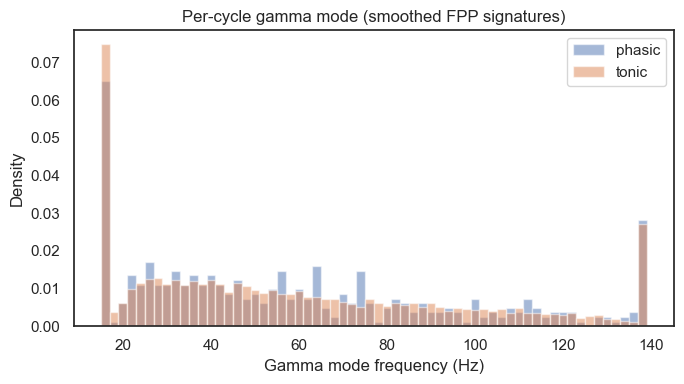

In [12]:
# --- histogram overlay ---
plt.figure(figsize=(7,4))
bins = np.arange(15, 141, 2)  # 2-Hz bins across your 15–140 Hz range

ph = df[df["cycle_type"]=="phasic"]["mode_freq_hz_smooth"].dropna().values
to = df[df["cycle_type"]=="tonic"]["mode_freq_hz_smooth"].dropna().values

plt.hist(ph, bins=bins, alpha=0.5, density=True, label="phasic")
plt.hist(to, bins=bins, alpha=0.5, density=True, label="tonic")

plt.xlabel("Gamma mode frequency (Hz)")
plt.ylabel("Density")
plt.title("Per-cycle gamma mode (smoothed FPP signatures)")
plt.legend()
plt.tight_layout()
plt.show()

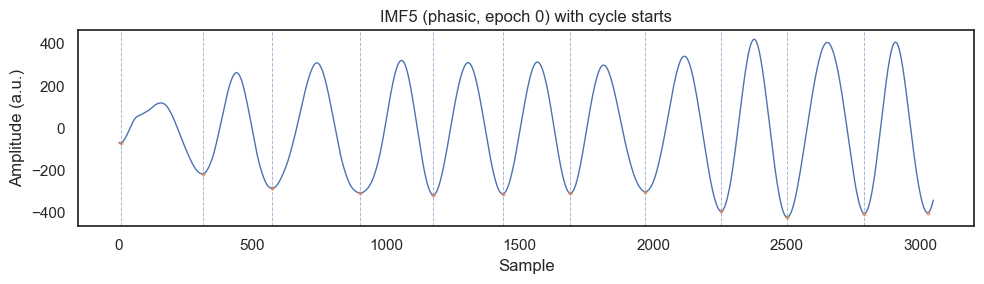

In [13]:
from scipy.signal import find_peaks  # only for optional trough markers

# choose one:
view_state = "phasic"   # or "tonic"
view_epoch = 0          # integer epoch index to view

imf5_list = imf5_dict[view_state]
if view_epoch >= len(imf5_list):
    raise IndexError(f"{view_state} has only {len(imf5_list)} epochs")

sig = imf5_list[view_epoch]
sub = df[(df["cycle_type"]==view_state) & (df["epoch_idx"]==view_epoch)].copy()
sub = sub.sort_values(["start_sample","end_sample"])

plt.figure(figsize=(10,3))
plt.plot(np.arange(len(sig)), sig, linewidth=1)
for _, row in sub.iterrows():
    plt.axvline(row["start_sample"], linestyle="--", linewidth=0.7, alpha=0.5)
# optional: mark troughs used by segmentation (purely illustrative)
troughs, _ = find_peaks(-sig)
plt.plot(troughs, sig[troughs], marker="o", linestyle="None", markersize=2, alpha=0.6)

plt.title(f"IMF5 ({view_state}, epoch {view_epoch}) with cycle starts")
plt.xlabel("Sample")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

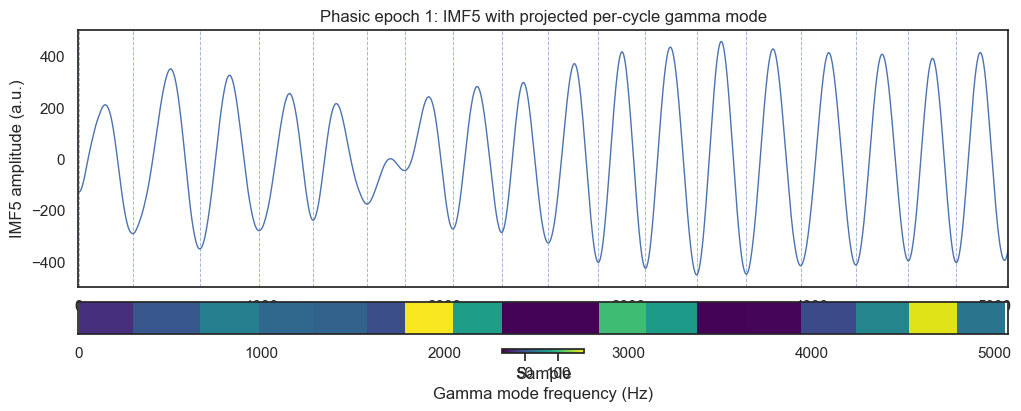

In [15]:
# ==== Project per-cycle mode frequency onto time for ONE PHASIC epoch ====
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- paths (adjust if needed)
csv_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/cycles_phasic_tonic_allcycles.csv"
pkl_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/exploration/imf5_per_epoch.pkl"

# --- load
df = pd.read_csv(csv_path)
with open(pkl_path, "rb") as f:
    imf5_dict = pickle.load(f)   # {"phasic": [ndarray per epoch], "tonic": [...]}

# --- choose which phasic epoch to visualize
epoch_idx = 1   # <-- change this to pick a different phasic epoch

# subset to that epoch's cycles
sub = df[(df["cycle_type"]=="phasic") & (df["epoch_idx"]==epoch_idx)].copy()
if sub.empty:
    raise ValueError(f"No cycles found for phasic epoch_idx={epoch_idx}")

# get the IMF5 signal for that epoch
phasic_imf5_list = imf5_dict["phasic"]
if epoch_idx >= len(phasic_imf5_list):
    raise IndexError(f"phasic has only {len(phasic_imf5_list)} epochs; epoch_idx={epoch_idx} is out of range.")
sig = phasic_imf5_list[epoch_idx]
n = len(sig)

# --- build per-sample projection of mode frequency
# initialize as NaN (samples not covered by any labeled cycle will stay NaN)
mode_per_sample = np.full(n, np.nan, dtype=float)

# sort cycles by start_sample for cleaner plotting
sub = sub.sort_values(["start_sample","end_sample"]).reset_index(drop=True)

# assign each sample within a cycle to that cycle's mode frequency
# end is treated as exclusive (start <= t < end)
for _, row in sub.iterrows():
    s = int(row["start_sample"])
    e = int(row["end_sample"])
    if s < 0: s = 0
    if e > n: e = n
    if e > s:
        mode_per_sample[s:e] = float(row["mode_freq_hz_smooth"])

# === PLOTTING ===
# Figure with two aligned panels:
#   1) IMF5 trace with cycle boundaries
#   2) color strip: per-sample mode frequency (Hz)
fig = plt.figure(figsize=(12,4.2))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3,0.6], hspace=0.1)

# (1) IMF5
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(n), sig, linewidth=1)
for _, row in sub.iterrows():
    ax1.axvline(int(row["start_sample"]), linestyle="--", linewidth=0.7, alpha=0.5)
ax1.set_xlim(0, n-1)
ax1.set_ylabel("IMF5 amplitude (a.u.)")
ax1.set_title(f"Phasic epoch {epoch_idx}: IMF5 with projected per-cycle gamma mode")

# (2) color strip for mode frequency (Hz)
ax2 = fig.add_subplot(gs[1,0], sharex=ax1)

# prepare a 2D row image for imshow (shape = 1 x n)
img = mode_per_sample[np.newaxis, :]  # shape (1, n)
# pick fixed vmin/vmax that match your analysis range
vmin, vmax = 15.0, 140.0
im = ax2.imshow(img, aspect="auto", interpolation="nearest",
                extent=[0, n-1, 0, 1], origin="lower",
                vmin=vmin, vmax=vmax, cmap="viridis")

# cosmetics
ax2.set_yticks([])
ax2.set_xlabel("Sample")
cbar = fig.colorbar(im, ax=ax2, orientation="horizontal", pad=0.3, fraction=0.08)
cbar.set_label("Gamma mode frequency (Hz)")

plt.tight_layout()
plt.show()

# --- OPTIONAL: export the projected vector (e.g., for stats)
# projected_mode_vector = mode_per_sample

In [17]:
import os
import pandas as pd
import pickle

# existing file paths
csv_path = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/cycles_phasic_tonic_allcycles.csv'
imf5_path = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/imf5_per_epoch.pkl'

# new save location
save_dir = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data"
os.makedirs(save_dir, exist_ok=True)
combined_pkl_path = os.path.join(save_dir, "rem_cycles_continuous.pkl")

# load both existing files
df = pd.read_csv(csv_path)
with open(imf5_path, "rb") as f:
    imf5_dict = pickle.load(f)

# combine into one object without metadata
combined_data = {
    "cycles_df": df,          # pandas DataFrame of all cycles
    "imf5_data": imf5_dict    # dict: {"phasic": [arrays], "tonic": [arrays]}
}

# save as single .pkl
with open(combined_pkl_path, "wb") as f:
    pickle.dump(combined_data, f)

print(f"✅ Saved combined dataset: {combined_pkl_path}")
print(f"- n cycles: {len(df)}")
print(f"- n phasic epochs: {len(imf5_dict['phasic'])}")
print(f"- n tonic epochs: {len(imf5_dict['tonic'])}")

✅ Saved combined dataset: /Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/rem_cycles_continuous.pkl
- n cycles: 9079
- n phasic epochs: 17
- n tonic epochs: 30


In [22]:
import pickle

path = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/rem_cycles_continuous.pkl'

with open(path, "rb") as f:
    data = pickle.load(f)

df = data["cycles_df"]          # pandas DataFrame
imf5_data = data["imf5_data"]   # dict with "phasic" and "tonic"

print(df.head())
print("Phasic epochs:", len(imf5_data["phasic"]))
print("Tonic epochs:", len(imf5_data["tonic"]))

  cycle_type  epoch_idx  cycle_idx_in_epoch  start_sample  end_sample  \
0     phasic          0                   0             6         313   
1     phasic          0                   1           313         573   
2     phasic          0                   2           573         904   
3     phasic          0                   3           904        1177   
4     phasic          0                   4          1177        1437   

   length_samples  mode_freq_hz_smooth  theta_imf_index  
0             307                 83.0                5  
1             260                113.0                5  
2             331                 37.0                5  
3             273                 16.0                5  
4             260                 22.0                5  
Phasic epochs: 17
Tonic epochs: 30


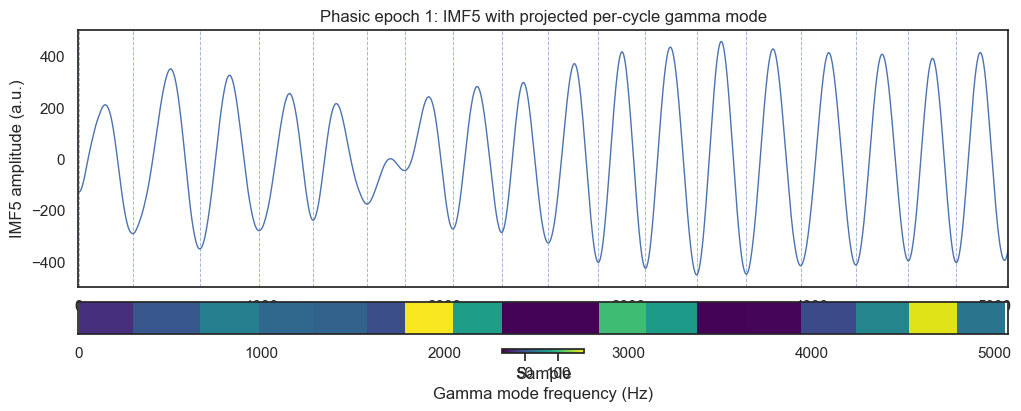

In [23]:
# ==== Project per-cycle mode frequency onto time for ONE PHASIC epoch ====
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- choose which phasic epoch to visualize
epoch_idx = 1   # <-- change this to pick a different phasic epoch

# subset to that epoch's cycles
sub = df[(df["cycle_type"]=="phasic") & (df["epoch_idx"]==epoch_idx)].copy()
if sub.empty:
    raise ValueError(f"No cycles found for phasic epoch_idx={epoch_idx}")

# get the IMF5 signal for that epoch
phasic_imf5_list = imf5_dict["phasic"]
if epoch_idx >= len(phasic_imf5_list):
    raise IndexError(f"phasic has only {len(phasic_imf5_list)} epochs; epoch_idx={epoch_idx} is out of range.")
sig = phasic_imf5_list[epoch_idx]
n = len(sig)

# --- build per-sample projection of mode frequency
# initialize as NaN (samples not covered by any labeled cycle will stay NaN)
mode_per_sample = np.full(n, np.nan, dtype=float)

# sort cycles by start_sample for cleaner plotting
sub = sub.sort_values(["start_sample","end_sample"]).reset_index(drop=True)

# assign each sample within a cycle to that cycle's mode frequency
# end is treated as exclusive (start <= t < end)
for _, row in sub.iterrows():
    s = int(row["start_sample"])
    e = int(row["end_sample"])
    if s < 0: s = 0
    if e > n: e = n
    if e > s:
        mode_per_sample[s:e] = float(row["mode_freq_hz_smooth"])

# === PLOTTING ===
# Figure with two aligned panels:
#   1) IMF5 trace with cycle boundaries
#   2) color strip: per-sample mode frequency (Hz)
fig = plt.figure(figsize=(12,4.2))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3,0.6], hspace=0.1)

# (1) IMF5
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(n), sig, linewidth=1)
for _, row in sub.iterrows():
    ax1.axvline(int(row["start_sample"]), linestyle="--", linewidth=0.7, alpha=0.5)
ax1.set_xlim(0, n-1)
ax1.set_ylabel("IMF5 amplitude (a.u.)")
ax1.set_title(f"Phasic epoch {epoch_idx}: IMF5 with projected per-cycle gamma mode")

# (2) color strip for mode frequency (Hz)
ax2 = fig.add_subplot(gs[1,0], sharex=ax1)

# prepare a 2D row image for imshow (shape = 1 x n)
img = mode_per_sample[np.newaxis, :]  # shape (1, n)
# pick fixed vmin/vmax that match your analysis range
vmin, vmax = 15.0, 140.0
im = ax2.imshow(img, aspect="auto", interpolation="nearest",
                extent=[0, n-1, 0, 1], origin="lower",
                vmin=vmin, vmax=vmax, cmap="viridis")

# cosmetics
ax2.set_yticks([])
ax2.set_xlabel("Sample")
cbar = fig.colorbar(im, ax=ax2, orientation="horizontal", pad=0.3, fraction=0.08)
cbar.set_label("Gamma mode frequency (Hz)")

plt.tight_layout()
plt.show()

# --- OPTIONAL: export the projected vector (e.g., for stats)
# projected_mode_vector = mode_per_sample

## v2

In [25]:
# ============================================================
# Faithful FPP version (no cycle filtering) + single PKL save
# ============================================================
import os, re, warnings, pickle
import numpy as np
import pandas as pd
import scipy.signal as spsig
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d

# ---------- Your originals ----------
def _morlet_amp_spectrogram(x, fs, freqs_hz, w=6.0):
    freqs_hz = np.asarray(freqs_hz, float)
    scales = (w * fs) / (2.0 * np.pi * freqs_hz)  # s = w*fs/(2π f)
    cwt_mat = spsig.cwt(x, spsig.morlet2, scales, w=w)
    return np.abs(cwt_mat)

def _choose_theta_imf(imf, fs, imf_centers_hz, theta_band=(5.0, 12.0), prefer_idx=5):
    if imf.shape[1] > prefer_idx:
        return prefer_idx
    lo, hi = theta_band
    centers = np.asarray(imf_centers_hz).astype(float)
    if centers.ndim == 1 and centers.size == imf.shape[1]:
        band_center = 0.5*(lo + hi)
        return int(np.argmin(np.abs(centers - band_center)))
    warnings.warn("Unexpected imf_centers_hz shape; defaulting to last IMF.")
    return imf.shape[1] - 1

def _cycle_bounds_from_inds(all_cycles_inds):
    bounds = []
    for cyc in all_cycles_inds:
        cyc = np.asarray(cyc)
        cyc = cyc[np.isfinite(cyc)]
        if cyc.size > 1:
            s, e = int(cyc[0]), int(cyc[-1])
            if e > s:
                bounds.append([s, e])
    return np.array(bounds, dtype=int)

# ---------- helpers to get ALL cycles (no filtering) ----------
def _fallback_trough_bounds(x, fs):
    """Trough-to-trough bounds if cycle object path isn't available."""
    # conservative minimum distance: ~ half-cycle at 12 Hz
    min_dist = max(1, int(fs / 24.0))
    troughs, _ = spsig.find_peaks(-np.asarray(x), distance=min_dist)
    if troughs.size < 2:
        return np.zeros((0, 2), dtype=int)
    b = np.column_stack([troughs[:-1], troughs[1:]])
    return b.astype(int)

def _all_cycle_bounds_from_cycleobj(cycle_obj, fs, theta_signal=None):
    """
    Try to get all cycles from your cycle object; if unavailable, use troughs.
    - Expected to work if cycle_obj.get_metric_dataframe() returns *all* cycles.
    """
    bounds = None
    # Try to use provided APIs, if present
    if hasattr(cycle_obj, "get_metric_dataframe"):
        try:
            mdf = cycle_obj.get_metric_dataframe()  # no subset=True → all cycles
            if "index" in mdf.columns:
                idx = mdf["index"].values
            else:
                # Some versions include one row per cycle already ordered
                idx = np.arange(len(mdf), dtype=int)
            # If you have a get_cycle_inds util:
            if "get_cycle_inds" in globals():
                try:
                    all_inds = get_cycle_inds(cycle_obj, idx)
                    bounds = _cycle_bounds_from_inds(all_inds)
                except Exception:
                    bounds = None
        except Exception:
            bounds = None

    # Fallback to troughs if needed
    if bounds is None or bounds.size == 0:
        if theta_signal is None:
            return np.zeros((0, 2), dtype=int)
        bounds = _fallback_trough_bounds(theta_signal, fs)
    return bounds

# ---------- YOUR FPP-based per-segment spectral signatures (all cycles) ----------
def spectral_signatures_from_fpp_for_segment_allcycles(
    imf, imf_centers_hz, fs,
    theta_band=(5,12),
    freq_vec=np.arange(15,141,1),
    morlet_w=6.0,
    n_bins=19,
    normalize='zscore',     # 'zscore' or 'none'
    smooth_sigma_hz=5.0,    # for mode extraction
    ignore_edge_bins=1,
):
    """
    Faithful to your original steps (Morlet → zscore (optional) → FPP binning → mean across phase bins),
    but uses *all* cycles (no is_good/duration/amp filtering).
    Returns:
      sigs_per_cycle : (n_cycles, n_freq)
      cycle_bounds   : (n_cycles, 2) [start, end) in samples
      mode_freq_hz   : (n_cycles,) smoothed spectral-signature mode per cycle
      theta_imf_idx  : int (chosen theta IMF)
    """
    # 1) choose theta IMF using your rule
    theta_idx = _choose_theta_imf(imf, fs, imf_centers_hz, theta_band=theta_band, prefer_idx=5)
    theta_sig = imf[:, theta_idx]

    # 2) cycle detection from your cycle machinery (no filtering), fallback to troughs
    cycle_data = get_cycle_data(theta_sig, fs=fs)
    if cycle_data is not None and 'cycles' in cycle_data:
        cycle_bounds = _all_cycle_bounds_from_cycleobj(cycle_data['cycles'], fs, theta_signal=theta_sig)
    else:
        cycle_bounds = _fallback_trough_bounds(theta_sig, fs)
    if cycle_bounds.size == 0:
        return np.zeros((0, len(freq_vec))), np.zeros((0,2), int), np.array([]), theta_idx

    # 3) supra-theta signal (sum IMFs > 12 Hz) using your tg_split helper
    sub_mask, theta_mask, supra_mask = tg_split(imf_centers_hz, theta_band)
    supra_theta_sig = imf[:, supra_mask].sum(axis=1) if np.any(supra_mask) else np.zeros(imf.shape[0])

    # 4) Morlet amplitude TFR (15–140 Hz) and optional per-frequency z-score
    tf_amp = _morlet_amp_spectrogram(supra_theta_sig, fs, freq_vec, w=morlet_w)  # [n_freq, n_time]
    if normalize == 'zscore':
        tf_use = zscore(tf_amp, axis=1)  # per-freq z across time (faithful to your code)
    elif normalize == 'none':
        tf_use = tf_amp
    else:
        raise ValueError("normalize must be 'zscore' or 'none'.")

    # 5) Per-cycle FPP → per-cycle spectral signature (mean across phase bins)
    sigs = []
    for (s, e) in cycle_bounds:
        fpp_single = bin_tf_to_fpp(np.array([s, e]), tf_use, bin_count=n_bins)  # [1, n_freq, n_bins]
        fpp_single = np.squeeze(fpp_single, axis=0)                            # [n_freq, n_bins]
        sig_single = np.nanmean(fpp_single, axis=1)                            # collapse phase bins → [n_freq]
        sigs.append(sig_single)
    if len(sigs) == 0:
        return np.zeros((0, len(freq_vec))), cycle_bounds, np.array([]), theta_idx
    sigs_per_cycle = np.vstack(sigs)

    # 6) smoothed "mode" (peak) frequency per cycle, like your smooth5 version
    mode_freqs = []
    lo, hi = ignore_edge_bins, (len(freq_vec) - ignore_edge_bins)
    for row in sigs_per_cycle:
        r = gaussian_filter1d(row, sigma=float(smooth_sigma_hz), axis=0, mode="reflect")
        if hi > lo:
            idx = lo + int(np.argmax(r[lo:hi]))
        else:
            idx = int(np.argmax(r))
        mode_freqs.append(float(freq_vec[idx]))
    mode_freqs = np.asarray(mode_freqs, float)

    return sigs_per_cycle, cycle_bounds, mode_freqs, theta_idx


# ---- paths (your example) ----
path_to_config  = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/src/emd_masksift_CA1_config_2500.yml'
path_to_hpc     = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/HPC_100_CH32_0.continuous.mat'
path_to_states  = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/2018-11-02_14-17-36_post_trial5-states.mat'
save_dir        = '/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data'
os.makedirs(save_dir, exist_ok=True)
combined_pkl    = os.path.join(save_dir, 'rem_cycles_full_dataset.pkl')

# ---- config & constants ----
config = SiftConfig.from_yaml_file(path_to_config)
fs = 2500
FREQ_VEC = np.arange(15, 141, 1)
THETA_BAND = (5, 12)
MORLET_W = 6.0
N_BINS = 19

# ---- load & segment REM substates ----
lfpHPC, hypno, fs_from_data = get_data(path_to_hpc, path_to_states)
if fs_from_data is not None:
    fs = fs_from_data
phasic_interval, tonic_interval, lfp = extract_pt_intervals(lfpHPC, hypno)

# ---- decompose per state ----
tonic_imfs,  tonic_freqs,  _ = extract_imfs_by_pt_intervals(lfp, fs, tonic_interval,  config, return_imfs_freqs=True)
phasic_imfs, phasic_freqs, _ = extract_imfs_by_pt_intervals(lfp, fs, phasic_interval, config, return_imfs_freqs=True)

# ---- collect per-epoch outputs (ALL cycles) ----
records = []              # rows for cycles_df
imf5_dict = {"phasic": [], "tonic": []}
phasic_time_sigs, tonic_time_sigs = [], []  # faithful FPP-derived spectral signatures

def _process_state(imf_list, freq_list, label):
    time_sigs_all = []
    for seg_idx, (imf_seg, centers_seg) in enumerate(zip(imf_list, freq_list)):
        if not isinstance(imf_seg, np.ndarray) or imf_seg.ndim != 2:
            continue
        # core extraction
        sigs, bounds, modes, theta_idx = spectral_signatures_from_fpp_for_segment_allcycles(
            imf_seg, centers_seg, fs,
            theta_band=THETA_BAND, freq_vec=FREQ_VEC,
            morlet_w=MORLET_W, n_bins=N_BINS, normalize='zscore',
            smooth_sigma_hz=5.0, ignore_edge_bins=1
        )
        # collect IMF5 for this epoch (theta carrier actually used)
        if imf_seg.shape[1] > theta_idx:
            imf5_dict[label].append(imf_seg[:, theta_idx].astype(float))
        else:
            imf5_dict[label].append(np.zeros(imf_seg.shape[0], float))

        time_sigs_all.append(sigs)  # (n_cycles, n_freq)

        # rows (cycle-level)
        for k, (s, e) in enumerate(bounds):
            records.append({
                "cycle_type": label,
                "epoch_idx": seg_idx,
                "cycle_idx_in_epoch": k,
                "start_sample": int(s),
                "end_sample": int(e),
                "length_samples": int(e - s),
                "mode_freq_hz_smooth": float(modes[k]) if len(modes) > k else np.nan,
                "theta_imf_index": int(theta_idx)
            })
    return time_sigs_all

phasic_time_sigs = _process_state(phasic_imfs, phasic_freqs, "phasic")
tonic_time_sigs  = _process_state(tonic_imfs,  tonic_freqs,  "tonic")

# ---- pack & save (single PKL, no meta) ----
cycles_df = pd.DataFrame.from_records(records)
bundle = {
    "cycles_df": cycles_df,                 # all cycles (no filtering), with smoothed mode freq
    "imf5_data": imf5_dict,                 # IMF(theta) per epoch actually used
    "phasic_time_sigs": phasic_time_sigs,   # list of arrays: (n_cycles_i, n_freq)
    "tonic_time_sigs":  tonic_time_sigs,    # list of arrays: (n_cycles_i, n_freq)
    "freq_vec": FREQ_VEC                    # frequency axis for time_sigs
}
with open(combined_pkl, "wb") as f:
    pickle.dump(bundle, f)

print(f"✅ Saved: {combined_pkl}")
print("Rows in cycles_df:", len(cycles_df))
print("Phasic epochs (IMF5 stored):", len(imf5_dict["phasic"]))
print("Tonic  epochs (IMF5 stored):", len(imf5_dict["tonic"]))

15-Oct-25 00:53:11 | WARNING | Hypnogram is SHORTER than data by 0.74 seconds. Padding hypnogram with last value to match data.size.


Number of detected Tonic intrevals:30
Number of detected Tonic intrevals after threshold:30
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from input 'IP'
 Checking Cycles inputs - trimming singleton from inpu

In [26]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

combined_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/rem_cycles_full_dataset.pkl"

with open(combined_path, "rb") as f:
    data = pickle.load(f)

cycles_df      = data["cycles_df"]          # per-cycle table (ALL cycles)
imf5_data      = data["imf5_data"]          # {"phasic":[arrays], "tonic":[arrays]}
phasic_sigs    = data["phasic_time_sigs"]   # list of (n_cycles_i x n_freq)
tonic_sigs     = data["tonic_time_sigs"]
freq_vec       = np.asarray(data["freq_vec"])

print(cycles_df.head())
print("N cycles:", len(cycles_df))
print("cycle_type counts:\n", cycles_df["cycle_type"].value_counts())

  cycle_type  epoch_idx  cycle_idx_in_epoch  start_sample  end_sample  \
0     phasic          0                   0             0         377   
1     phasic          0                   1           307         665   
2     phasic          0                   2           577         995   
3     phasic          0                   3           903        1241   
4     phasic          0                   4          1176        1502   

   length_samples  mode_freq_hz_smooth  theta_imf_index  
0             377                 85.0                5  
1             358                110.0                5  
2             418                 38.0                5  
3             338                 16.0                5  
4             326                 23.0                5  
N cycles: 9037
cycle_type counts:
 cycle_type
tonic     8632
phasic     405
Name: count, dtype: int64


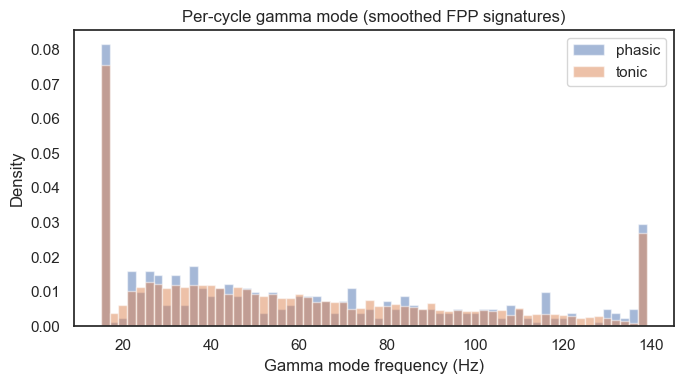

In [27]:
plt.figure(figsize=(7,4))
bins = np.arange(15, 141, 2)

ph = cycles_df.loc[cycles_df["cycle_type"]=="phasic","mode_freq_hz_smooth"].dropna().values
to = cycles_df.loc[cycles_df["cycle_type"]=="tonic","mode_freq_hz_smooth"].dropna().values

plt.hist(ph, bins=bins, alpha=0.5, density=True, label="phasic")
plt.hist(to, bins=bins, alpha=0.5, density=True, label="tonic")

plt.xlabel("Gamma mode frequency (Hz)")
plt.ylabel("Density")
plt.title("Per-cycle gamma mode (smoothed FPP signatures)")
plt.legend()
plt.tight_layout()
plt.show()

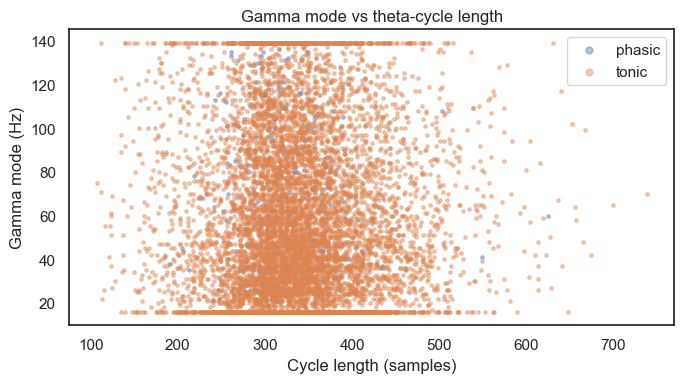

In [28]:
plt.figure(figsize=(7,4))
m = cycles_df["cycle_type"]=="phasic"
plt.scatter(cycles_df.loc[m,"length_samples"], cycles_df.loc[m,"mode_freq_hz_smooth"],
            s=6, alpha=0.4, label="phasic")
m = cycles_df["cycle_type"]=="tonic"
plt.scatter(cycles_df.loc[m,"length_samples"], cycles_df.loc[m,"mode_freq_hz_smooth"],
            s=6, alpha=0.4, label="tonic")

plt.xlabel("Cycle length (samples)")
plt.ylabel("Gamma mode (Hz)")
plt.title("Gamma mode vs theta-cycle length")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

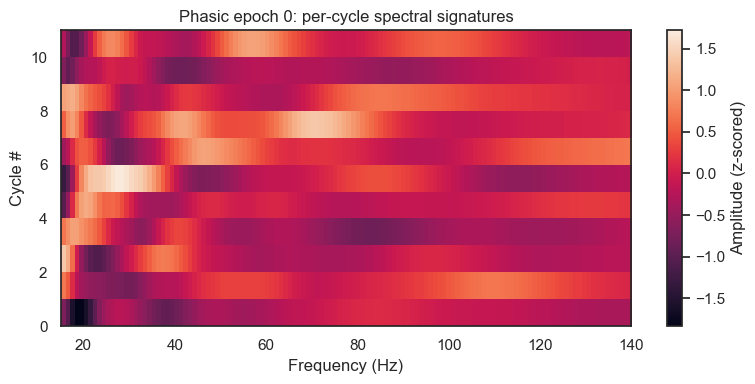

In [29]:
# example: visualize per-cycle signatures for the same epoch as a heatmap
sigs = phasic_sigs[view_epoch] if view_state=="phasic" else tonic_sigs[view_epoch]
if isinstance(sigs, np.ndarray) and sigs.size:
    plt.figure(figsize=(8,4))
    plt.imshow(sigs, aspect="auto", origin="lower",
               extent=[freq_vec.min(), freq_vec.max(), 0, sigs.shape[0]])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Cycle #")
    plt.title(f"{view_state.capitalize()} epoch {view_epoch}: per-cycle spectral signatures")
    plt.colorbar(label="Amplitude (z-scored)")
    plt.tight_layout()
    plt.show()
else:
    print("No signatures for this epoch.")

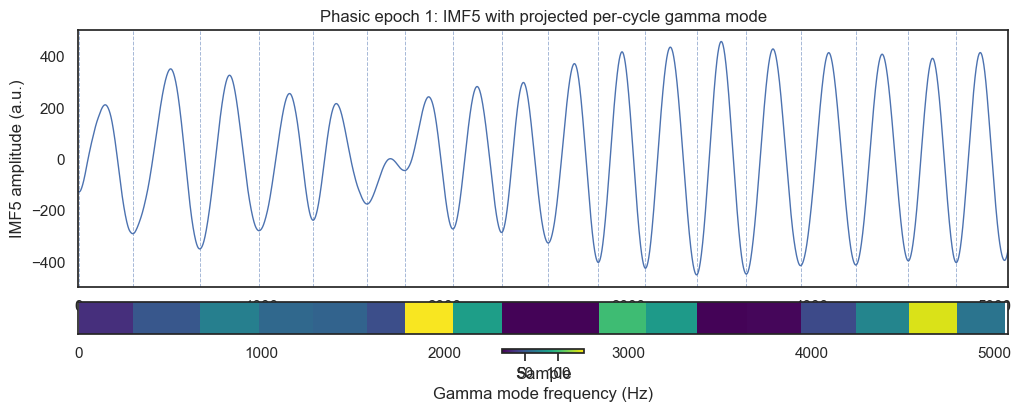

In [30]:
# ==== Load combined PKL and project per-cycle mode frequency onto time for ONE PHASIC epoch ====
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- load the single PKL you saved
combined_path = "/Users/amir/Desktop/for Abdel/thetaGamma_dev/data/topology_data/rem_cycles_full_dataset.pkl"
with open(combined_path, "rb") as f:
    data = pickle.load(f)

# make variables compatible with your existing snippet
df = data["cycles_df"]            # pandas DataFrame
imf5_dict = data["imf5_data"]     # {"phasic": [arrays], "tonic": [arrays]}

# --- choose which phasic epoch to visualize
epoch_idx = 1   # <-- change this to pick a different phasic epoch

# subset to that epoch's cycles
sub = df[(df["cycle_type"]=="phasic") & (df["epoch_idx"]==epoch_idx)].copy()
if sub.empty:
    raise ValueError(f"No cycles found for phasic epoch_idx={epoch_idx}")

# get the IMF5 signal for that epoch
phasic_imf5_list = imf5_dict["phasic"]
if epoch_idx >= len(phasic_imf5_list):
    raise IndexError(f"phasic has only {len(phasic_imf5_list)} epochs; epoch_idx={epoch_idx} is out of range.")
sig = np.asarray(phasic_imf5_list[epoch_idx], float)
n = len(sig)

# --- build per-sample projection of mode frequency (NaN outside cycles)
mode_per_sample = np.full(n, np.nan, dtype=float)

# sort cycles by start_sample for cleaner plotting
sub = sub.sort_values(["start_sample","end_sample"]).reset_index(drop=True)

# assign each sample within a cycle to that cycle's mode frequency (end exclusive)
for _, row in sub.iterrows():
    s = int(row["start_sample"])
    e = int(row["end_sample"])
    s = max(0, s)
    e = min(n, e)
    if e > s:
        mode_per_sample[s:e] = float(row["mode_freq_hz_smooth"])

# === PLOTTING ===
fig = plt.figure(figsize=(12,4.2))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3,0.6], hspace=0.1)

# (1) IMF5 trace with cycle starts
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(n), sig, linewidth=1)
for _, row in sub.iterrows():
    ax1.axvline(int(row["start_sample"]), linestyle="--", linewidth=0.7, alpha=0.5)
ax1.set_xlim(0, n-1)
ax1.set_ylabel("IMF5 amplitude (a.u.)")
ax1.set_title(f"Phasic epoch {epoch_idx}: IMF5 with projected per-cycle gamma mode")

# (2) color strip: per-sample mode frequency (Hz)
ax2 = fig.add_subplot(gs[1,0], sharex=ax1)
img = mode_per_sample[np.newaxis, :]  # shape (1, n)
im = ax2.imshow(img, aspect="auto", interpolation="nearest",
                extent=[0, n-1, 0, 1], origin="lower",
                vmin=15.0, vmax=140.0, cmap="viridis")
ax2.set_yticks([])
ax2.set_xlabel("Sample")
cbar = fig.colorbar(im, ax=ax2, orientation="horizontal", pad=0.3, fraction=0.08)
cbar.set_label("Gamma mode frequency (Hz)")

plt.tight_layout()
plt.show()

# OPTIONAL: the per-sample vector is in `mode_per_sample`